In [2]:
import gc
import json
import os
import warnings
from pathlib import Path
from tempfile import TemporaryDirectory

warnings.filterwarnings("ignore")

import numpy as np
for name, value in [("int", int), ("float", float), ("bool", bool), ("object", object), ("complex", complex)]:
    if name not in np.__dict__:
        setattr(np, name, value)

import pandas as pd
from IPython import get_ipython
_ipython = get_ipython()
if _ipython is not None:
    _ipython.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerBase
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle
from scipy.ndimage import gaussian_filter, uniform_filter
from scipy.spatial import cKDTree
from scipy.stats import rankdata

FIGURE_STYLE = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Liberation Sans", "DejaVu Sans"],
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 0.6,
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.grid": False,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "legend.frameon": False,
    "figure.dpi": 180,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
}

def apply_figure_style():
    plt.rcParams.update(FIGURE_STYLE)


def style_panel(axis):
    axis.set_facecolor("white")
    axis.grid(False)
    for spine in axis.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.6)
    axis.tick_params(direction="out", colors="black", width=0.6, length=3.5)


def facet_strip(axis, label, fontsize=12, height=0.095):
    strip = Rectangle(
        (0, 1), 1, height, transform=axis.transAxes, clip_on=False,
        facecolor="white", edgecolor="black", linewidth=0.6, zorder=4,
    )
    axis.add_patch(strip)
    axis.text(
        0.5, 1 + height / 2, label, transform=axis.transAxes,
        ha="center", va="center", fontsize=fontsize, fontweight="bold", zorder=5,
    )


apply_figure_style()

BUNDLE_ROOT = Path(os.getenv("GHIST_BUNDLE_ROOT") or "../bundle").expanduser()

CONFIG = {
    "ground_truth": BUNDLE_ROOT / "evaluation_data/imputation/figure3_ground_truth.csv.gz",
    "coordinates": BUNDLE_ROOT / "evaluation_data/imputation/figure3_coordinates.csv.gz",
    "holdouts": BUNDLE_ROOT / "GHIST_plus/models/imputation/holdout_genes_by_slide.json",
    "imputation": {
        "GHIST+": BUNDLE_ROOT / "GHIST_plus/predictions/imputation/slide{slide}_imputed10_scaled.csv",
        "PASTA": BUNDLE_ROOT / "other_models/imputation/pasta/slide_{slide}_pasta_holdout_pred.csv",
        "SpatialEx": BUNDLE_ROOT / "other_models/imputation/spatialex_single_breast2_uni2h/slide{slide}_spatialex_single_breast2_uni2h_native_log.csv",
        "SpatialEx+": BUNDLE_ROOT / "other_models/imputation/spatialex_plus_uni2h/slide{slide}_spatialex_plus_fixed10_native_log.csv",
    },
    "ablation_ground_truth": BUNDLE_ROOT / "evaluation_data/breast2/cell_gene_matrix_filtered.csv",
    "ablation_coordinates": BUNDLE_ROOT / "evaluation_data/breast2/cell_coords.csv",
    "ablation": {
        "Full model": BUNDLE_ROOT / "GHIST_plus/predictions/breast_single/trainval_slide3_pred_expr_scaled.csv",
        "VQ composition off": BUNDLE_ROOT / "GHIST_plus/predictions/vq_off/vq_composition_off_trainval_slide3_pred_expr_scaled.csv",
        "Randomized VQ composition": BUNDLE_ROOT / "GHIST_plus/predictions/vq_off/randomized_vq_composition_trainval_slide3_pred_expr_scaled.csv",
    },
}

SLIDES = [0, 1, 2, 4, 5]
METHODS = ["GHIST+", "PASTA", "SpatialEx", "SpatialEx+"]
COLORS = {"GHIST+": "#D1495B", "PASTA": "#72B7A1", "SpatialEx": "#4C8DB8", "SpatialEx+": "#7A6BB7"}
SLIDE_LABELS = {0: "BreastCancer1", 1: "BreastCancerIDC", 5: "BreastCancerIDC2", 2: "BreastCancerILC", 4: "BreastCancerIDC3"}

with CONFIG["holdouts"].open() as handle:
    HOLDOUTS = json.load(handle)["genes_by_slide"]

ABLATION = CONFIG["ablation"]
_FIG4_TEMP = TemporaryDirectory(prefix="figure4_notebook_")
FIG4F_OUTPUT_DIR = Path(_FIG4_TEMP.name) / "f"

In [3]:
def holdout_genes(slide):
    return [str(gene) for gene in HOLDOUTS[str(slide)]]


def slide_path(method, slide):
    return Path(str(CONFIG["imputation"][method]).format(slide=slide))


def read_matrix(path, genes=None):
    path = Path(path)
    columns = pd.read_csv(path, nrows=0).columns.astype(str).tolist()
    id_column = "c_id" if "c_id" in columns else "cell_id" if "cell_id" in columns else columns[0]
    chosen = columns if genes is None else [id_column, *[gene for gene in genes if gene in columns]]
    frame = pd.read_csv(path, usecols=chosen)
    frame = frame.rename(columns={id_column: "cell_id"})
    frame["cell_id"] = frame["cell_id"].astype(str).str.strip()
    frame = frame.set_index("cell_id")
    frame.columns = frame.columns.astype(str)
    if frame.index.has_duplicates or frame.columns.has_duplicates:
        raise ValueError(path)
    return frame.astype(float)


def read_coordinates(path):
    frame = pd.read_csv(path)
    id_column = "cell_id" if "cell_id" in frame else "c_id" if "c_id" in frame else frame.columns[0]
    x = "x_coord" if "x_coord" in frame else "x"
    y = "y_coord" if "y_coord" in frame else "y"
    frame = frame.rename(columns={id_column: "cell_id", x: "x", y: "y"})
    frame["cell_id"] = frame["cell_id"].astype(str).str.strip()
    return frame.set_index("cell_id")[["x", "y"]].astype(float)


def read_slide_tables(path):
    frame = pd.read_csv(path, dtype={"cell_id": str}, float_precision="round_trip")
    required = {"slide_id", "cell_id"}
    missing = required.difference(frame.columns)
    if missing:
        raise ValueError(f"{path} is missing columns: {sorted(missing)}")
    frame["slide_id"] = pd.to_numeric(frame["slide_id"], errors="raise").astype(int)
    frame["cell_id"] = frame["cell_id"].astype(str).str.strip()
    if frame.duplicated(["slide_id", "cell_id"]).any():
        raise ValueError(f"Duplicate slide/cell keys in {path}")
    return {
        int(slide): part.drop(columns="slide_id").set_index("cell_id").astype(float)
        for slide, part in frame.groupby("slide_id", sort=False)
    }


GROUND_TRUTH = read_slide_tables(CONFIG["ground_truth"])
COORDINATES = read_slide_tables(CONFIG["coordinates"])


def load_imputation_slide(slide):
    requested = holdout_genes(slide)
    gt_all = GROUND_TRUTH[slide]
    genes = [gene for gene in requested if gene in gt_all and gt_all[gene].notna().all()]
    gt = gt_all.loc[:, genes]
    coordinates = COORDINATES[slide]
    if not gt.index.equals(coordinates.index):
        raise ValueError(f"Slide {slide}: GT/coordinate cohort mismatch")

    raw = {
        method: read_matrix(slide_path(method, slide), genes)
        for method in METHODS
    }
    for method, frame in raw.items():
        missing_genes = [gene for gene in genes if gene not in frame]
        missing_cells = gt.index.difference(frame.index)
        if missing_genes or len(missing_cells):
            raise ValueError(
                f"Slide {slide}, {method}: missing genes={missing_genes}, cells={len(missing_cells)}"
            )
        raw[method] = frame.loc[gt.index, genes]

    target_raw = gt.to_numpy(float)
    if not np.isfinite(target_raw).all() or np.min(target_raw) < 0:
        raise ValueError(f"Slide {slide}: invalid raw ground truth")
    target = np.log1p(target_raw)
    prediction = {
        method: frame.to_numpy(float)
        for method, frame in raw.items()
    }
    prediction["GHIST+"] /= 2
    prediction["PASTA"] = np.log1p(np.clip(prediction["PASTA"], 0, None))
    if not all(np.isfinite(values).all() for values in prediction.values()):
        raise ValueError(f"Slide {slide}: non-finite predictions")

    return {
        "genes": genes,
        "ids": gt.index,
        "target": target,
        "prediction": prediction,
        "xy": coordinates.loc[gt.index, ["x", "y"]].to_numpy(float),
    }


SLIDE_DATA = {slide: load_imputation_slide(slide) for slide in SLIDES}
if sum(len(data["genes"]) for data in SLIDE_DATA.values()) != 45:
    raise ValueError("Expected 45 shared slide-gene cases")


def public_path(path):
    return Path(path).relative_to(BUNDLE_ROOT).as_posix()


def common_ids(*frames):
    ids = frames[0].index
    for frame in frames[1:]:
        ids = ids.intersection(frame.index, sort=False)
    return ids


def pearson(target, prediction):
    target = np.asarray(target, float)
    prediction = np.asarray(prediction, float)
    if len(target) < 2 or np.std(target) == 0 or np.std(prediction) == 0:
        return np.nan
    return float(np.corrcoef(target, prediction)[0, 1])


def finite_nonconstant_columns(*matrices):
    valid = np.ones(matrices[0].shape[1], dtype=bool)
    for matrix in matrices:
        valid &= np.isfinite(matrix).all(axis=0)
        valid &= matrix.std(axis=0) > 0
    return valid


def cmd_eq17(target, prediction, columns, epsilon=1e-12):
    target = target[:, columns]
    prediction = prediction[:, columns]
    if target.shape[1] < 2:
        return np.nan
    target_correlation = np.corrcoef(target, rowvar=False)
    prediction_correlation = np.corrcoef(prediction, rowvar=False)
    numerator = float(np.trace(prediction_correlation @ target_correlation))
    denominator = float(np.linalg.norm(prediction_correlation, "fro") * np.linalg.norm(target_correlation, "fro") + epsilon)
    return 1.0 - numerator / denominator


def spatial_grid(x, y, width=400):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    height = max(20, int(round(width * np.ptp(y) / np.ptp(x))))
    xi = np.clip(((x - x.min()) / np.ptp(x) * (width - 1)).astype(np.int32), 0, width - 1)
    yi = np.clip(((y - y.min()) / np.ptp(y) * (height - 1)).astype(np.int32), 0, height - 1)
    index = yi * width + xi
    count = np.bincount(index, minlength=height * width).reshape(height, width).astype(float)
    occupied_y, occupied_x = np.where(count > 0)
    crop = (slice(occupied_y.min(), occupied_y.max() + 1), slice(occupied_x.min(), occupied_x.max() + 1))
    return height, width, index, count, crop


def spatial_mean_map(values, grid):
    height, width, index, count, crop = grid
    sums = np.bincount(index, weights=np.asarray(values, float), minlength=height * width).reshape(height, width)
    means = np.divide(sums, count, out=np.zeros_like(sums), where=count > 0)
    return gaussian_filter(means, sigma=1, mode="nearest", truncate=4)[crop]


def ssim(target, prediction, grid, window=7):
    target_map = spatial_mean_map(target, grid)
    prediction_map = spatial_mean_map(prediction, grid)
    data_range = np.ptp(target_map)
    if data_range <= 0:
        return np.nan
    arguments = {"size": window, "mode": "reflect", "origin": 0}
    mean_target = uniform_filter(target_map, **arguments)
    mean_prediction = uniform_filter(prediction_map, **arguments)
    factor = window ** 2 / (window ** 2 - 1)
    variance_target = factor * (uniform_filter(target_map * target_map, **arguments) - mean_target ** 2)
    variance_prediction = factor * (uniform_filter(prediction_map * prediction_map, **arguments) - mean_prediction ** 2)
    covariance = factor * (uniform_filter(target_map * prediction_map, **arguments) - mean_target * mean_prediction)
    c1 = (0.01 * data_range) ** 2
    c2 = (0.03 * data_range) ** 2
    numerator = (2 * mean_target * mean_prediction + c1) * (2 * covariance + c2)
    denominator = (mean_target ** 2 + mean_prediction ** 2 + c1) * (variance_target + variance_prediction + c2)
    score = np.divide(numerator, denominator, out=np.full_like(numerator, np.nan), where=denominator != 0)
    border = (window - 1) // 2
    return float(np.mean(score[border:-border, border:-border]))


def tissue_calibration(target, prediction, neighbors):
    target = np.asarray(target, np.float64)
    prediction = np.asarray(prediction, np.float64)
    local = prediction[neighbors]
    center_norm = np.linalg.norm(prediction, axis=1, keepdims=True)
    local_norm = np.linalg.norm(local, axis=2)
    cosine = np.einsum("ij,ikj->ik", prediction, local) / (center_norm * local_norm + 1e-12)
    weights = np.exp(np.clip(cosine, -50, 50))
    variance = (weights[:, :, None] * (local - prediction[:, None, :]) ** 2).sum(1) / (weights.sum(1)[:, None] + 1e-12)
    uncertainty = np.sqrt(np.maximum(variance, 0)) + 1
    return np.median(np.abs(target - prediction) / (uncertainty + 1e-12), axis=0)


def q99_scale(values):
    values = np.asarray(values, float)
    high = np.quantile(values, 0.99)
    return np.clip(values / high, 0, 1) if high > 0 else np.zeros_like(values)


class BoxplotLegendHandler(HandlerBase):
    def create_artists(self, legend, handle, xdescent, ydescent, width, height, fontsize, transform):
        edge = "#333333"
        center_x = xdescent + width / 2
        box_width, box_height = width * 0.72, height * 0.56
        box_x = center_x - box_width / 2
        box_y = ydescent + (height - box_height) / 2
        whisker = Line2D([center_x, center_x], [ydescent, ydescent + height], color=edge, linewidth=1.4, transform=transform)
        box = Rectangle((box_x, box_y), box_width, box_height, facecolor=handle.get_facecolor(), edgecolor=edge, linewidth=1.4, transform=transform)
        median = Line2D([box_x, box_x + box_width], [box_y + box_height / 2] * 2, color=edge, linewidth=1.4, transform=transform)
        return [whisker, box, median]


def boxplot_methods(axis, frame, suffix, group_label=None):
    values = [pd.to_numeric(frame[f"{method} {suffix}"], errors="coerce").dropna().to_numpy() for method in METHODS]
    positions = None
    widths = 0.55
    if group_label is not None:
        positions = 1 + (np.arange(len(METHODS)) - 1.5) * (0.9 / len(METHODS))
        widths = 0.75 / len(METHODS)
    plot = axis.boxplot(
        values, positions=positions, patch_artist=True, widths=widths, showfliers=True, showcaps=False,
        boxprops={"edgecolor": "#333333", "linewidth": 1.4},
        medianprops={"color": "#333333", "linewidth": 1.4},
        whiskerprops={"color": "#333333", "linewidth": 1.4},
        flierprops={"marker": "o", "markersize": 4.2, "markerfacecolor": "#333333", "markeredgewidth": 0, "alpha": 1.0},
    )
    for patch, method in zip(plot["boxes"], METHODS):
        patch.set_facecolor(COLORS[method])
    if group_label is None:
        axis.set_xticks(range(1, 5), METHODS, rotation=60, ha="right")
    else:
        axis.set_xticks([1], [group_label], rotation=60, ha="right")
        axis.set_xlim(0.45, 1.55)
    style_panel(axis)


def grouped_bars(axis, frame, suffix, ylabel):
    frame = frame.set_index("Slide").loc[[0, 1, 5, 2, 4]].reset_index()
    x = np.arange(len(frame))
    width = 0.19
    for offset, method in enumerate(METHODS):
        values = frame[f"{method} {suffix}"].to_numpy(float)
        bars = axis.bar(x + (offset - 1.5) * width, values, width, color=COLORS[method], label=method)
        for bar, value in zip(bars, values):
            label_y = value + 0.015 * (offset % 2)
            axis.text(bar.get_x() + bar.get_width() / 2, label_y, str(round(float(value), 2)), ha="center", va="bottom", fontsize=6)
    axis.set_xticks(x, [SLIDE_LABELS[int(slide)] for slide in frame["Slide"]], rotation=60, ha="right")
    axis.set_ylabel(ylabel)
    axis.set_ylim(0, 1)
    axis.set_yticks(np.arange(0, 1.01, 0.25))
    style_panel(axis)


def ablation_pearson(target, prediction):
    target = np.asarray(target, np.float64)
    prediction = np.asarray(prediction, np.float64)
    if target.shape != prediction.shape or target.ndim != 2:
        raise ValueError(f"PCC shape mismatch: target={target.shape}, prediction={prediction.shape}")
    output = np.full(target.shape[1], np.nan, np.float64)
    for gene_idx in range(target.shape[1]):
        valid = np.isfinite(target[:, gene_idx]) & np.isfinite(prediction[:, gene_idx])
        if valid.sum() < 2:
            continue
        observed = target[valid, gene_idx]
        estimated = prediction[valid, gene_idx]
        if np.std(observed) == 0 or np.std(estimated) == 0:
            continue
        value = np.corrcoef(observed, estimated)[0, 1]
        if np.isfinite(value):
            output[gene_idx] = value
    return output

def giotto_scores(expression, coordinates, k=8):
    neighbors = cKDTree(coordinates).query(coordinates, k=k + 1)[1][:, 1:]
    expression = np.asarray(expression, np.float32)
    scores = np.zeros(expression.shape[1], np.float32)
    for gene in range(expression.shape[1]):
        ranks = rankdata(expression[:, gene], method="average").astype(np.float32)
        local = ranks[neighbors].mean(1)
        ranks = ranks - ranks.mean()
        local = local - local.mean()
        denominator = np.sqrt((ranks ** 2).sum() * (local ** 2).sum())
        if denominator > 0:
            scores[gene] = np.dot(ranks, local) / denominator
    return scores

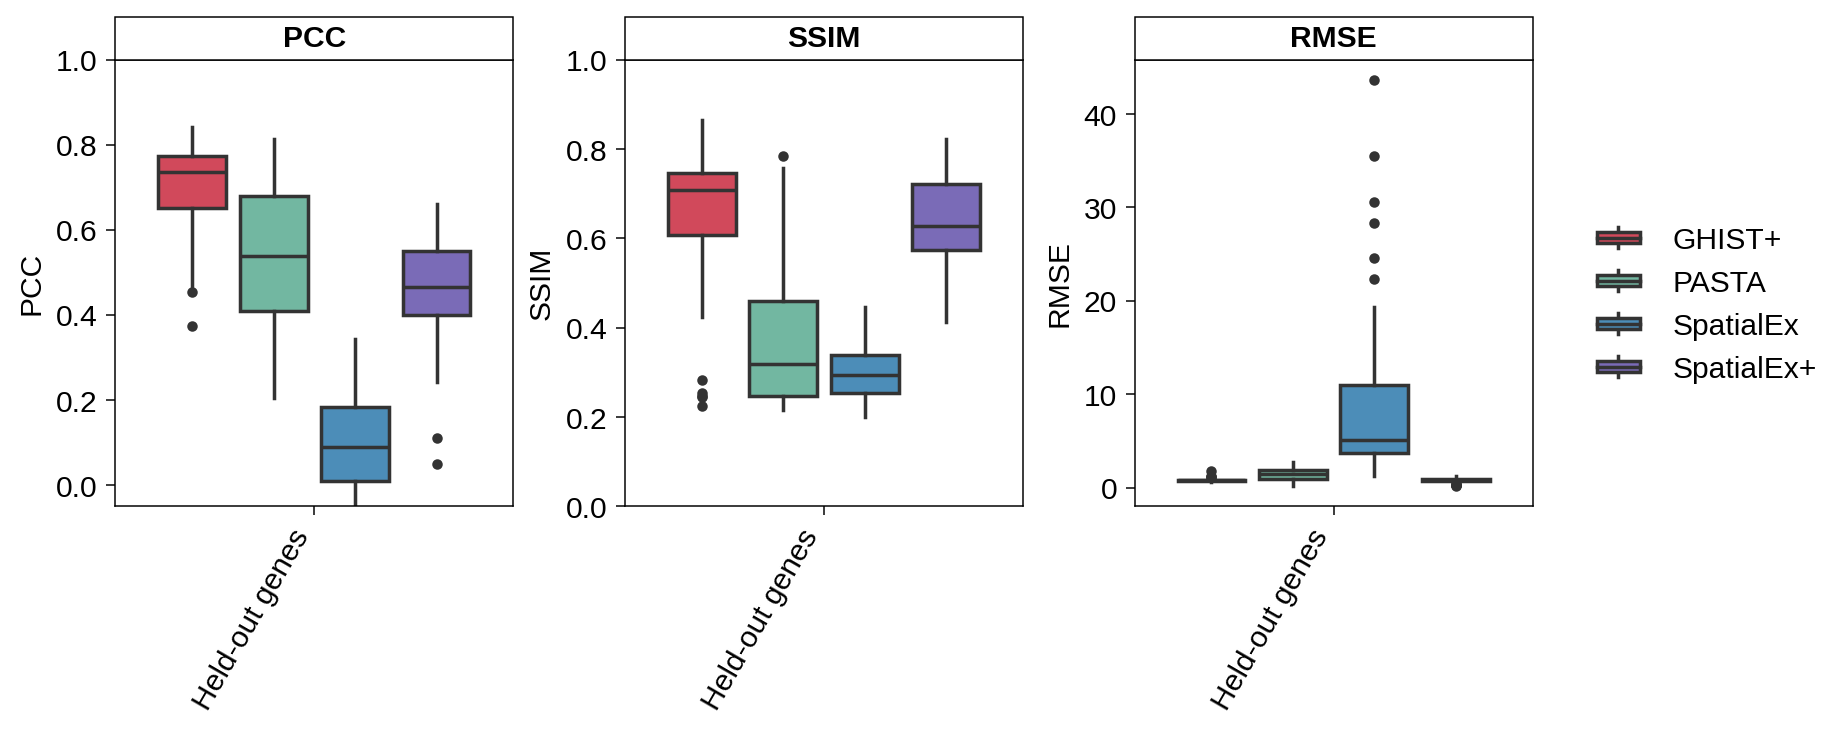

In [4]:
def compute_figure4a():
    pcc_rows, ssim_rows, rmse_rows = [], [], []
    for slide in SLIDES:
        data = SLIDE_DATA[slide]
        genes = data["genes"]
        target = data["target"]
        prediction = data["prediction"]
        grid = spatial_grid(data["xy"][:, 0], data["xy"][:, 1])

        for index, gene in enumerate(genes):
            pcc_row = {"Slide": slide, "Gene": gene}
            ssim_row = {"Slide": slide, "Gene": gene}
            rmse_row = {"Slide": slide, "Gene": gene}
            for method in METHODS:
                values = prediction[method][:, index]
                pcc_row[f"{method} PCC"] = pearson(target[:, index], values)
                ssim_row[f"{method} SSIM"] = ssim(target[:, index], values, grid)
                rmse_row[f"{method} RMSE"] = float(
                    np.sqrt(np.mean((target[:, index] - values) ** 2))
                )
            pcc_rows.append(pcc_row)
            ssim_rows.append(ssim_row)
            rmse_rows.append(rmse_row)
        gc.collect()

    metric_columns = lambda metric: [f"{method} {metric}" for method in METHODS]
    return (
        pd.DataFrame(pcc_rows),
        pd.DataFrame(ssim_rows)[metric_columns("SSIM")],
        pd.DataFrame(rmse_rows)[metric_columns("RMSE")],
    )


fig4a_pcc, fig4a_ssim, fig4a_rmse = compute_figure4a()
fig4a_coverage = {
    method: [
        fig4a_pcc[f"{method} PCC"].notna().sum(),
        fig4a_ssim[f"{method} SSIM"].notna().sum(),
        fig4a_rmse[f"{method} RMSE"].notna().sum(),
    ]
    for method in METHODS
}
if len(fig4a_pcc) != 45 or any(count != 45 for counts in fig4a_coverage.values() for count in counts):
    raise ValueError(f"Expected 45 common slide-gene cases for every Fig. 4a method/metric, found {fig4a_coverage}")
fig, axes = plt.subplots(1, 3, figsize=(10.5, 4.0))
for axis, frame, metric in zip(axes, [fig4a_pcc, fig4a_ssim, fig4a_rmse], ["PCC", "SSIM", "RMSE"]):
    boxplot_methods(axis, frame, metric, group_label="Held-out genes")
    facet_strip(axis, metric)
    axis.set_ylabel(metric)
axes[0].set_ylim(-0.05, 1)
axes[1].set_ylim(0, 1)
handles = [Patch(facecolor=COLORS[method], edgecolor="#333333", linewidth=0.8) for method in METHODS]
fig.legend(handles, METHODS, handler_map={Patch: BoxplotLegendHandler()}, frameon=False, loc="center left", bbox_to_anchor=(0.835, 0.50))
fig.subplots_adjust(left=0.07, right=0.82, bottom=0.22, top=0.84, wspace=0.28)
plt.show()

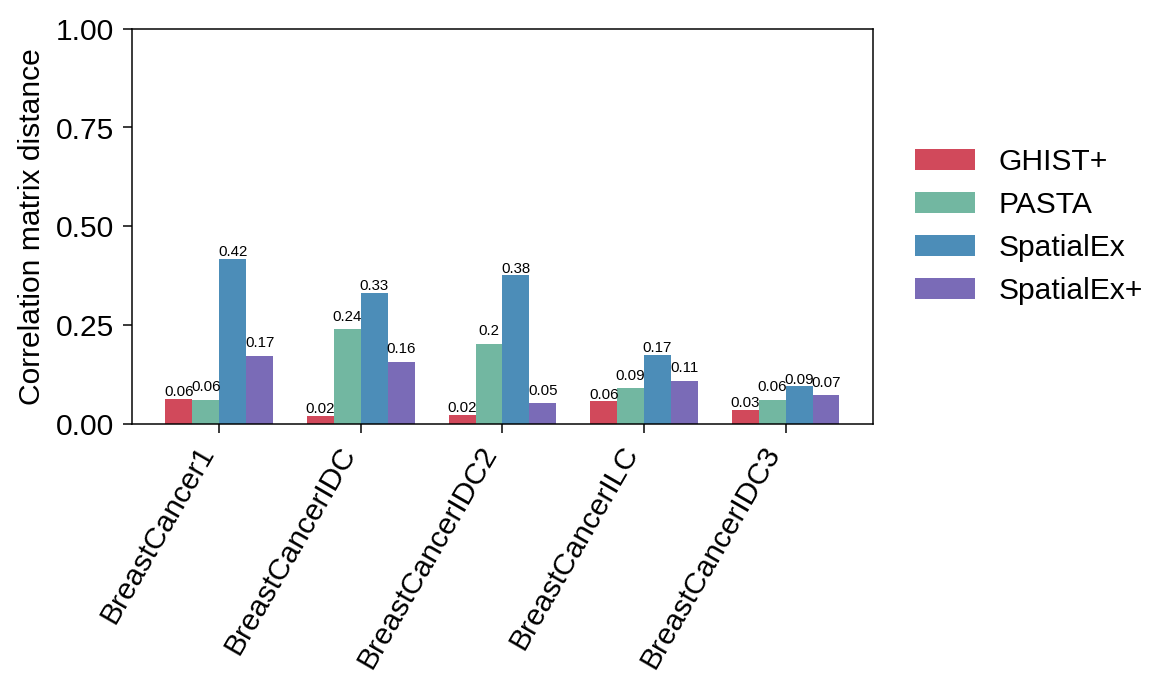

In [5]:
def compute_figure4b():
    rows = []
    for slide in SLIDES:
        data = SLIDE_DATA[slide]
        target = data["target"]
        prediction = data["prediction"]
        valid = finite_nonconstant_columns(
            target, *[prediction[method] for method in METHODS]
        )
        rows.append({
            "Slide": slide,
            **{
                f"{method} CMD": cmd_eq17(target, prediction[method], valid)
                for method in METHODS
            },
            "Cell count": len(data["ids"]),
            "Holdout gene count": len(data["genes"]),
            "CMD valid gene count": int(valid.sum()),
        })
    return pd.DataFrame(rows)


fig4b_cmd = compute_figure4b()
if int(fig4b_cmd["Holdout gene count"].sum()) != 45:
    raise ValueError(f"Expected 45 common slide-gene cases for Fig. 4b, found {int(fig4b_cmd['Holdout gene count'].sum())}")
if not fig4b_cmd["CMD valid gene count"].equals(fig4b_cmd["Holdout gene count"]):
    raise ValueError("CMD valid-gene coverage differs from the shared holdout cohort")
fig, axis = plt.subplots(figsize=(8, 4))
grouped_bars(axis, fig4b_cmd, "CMD", "Correlation matrix distance")
axis.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5))
fig.tight_layout(rect=(0, 0, 0.84, 1))
plt.show()

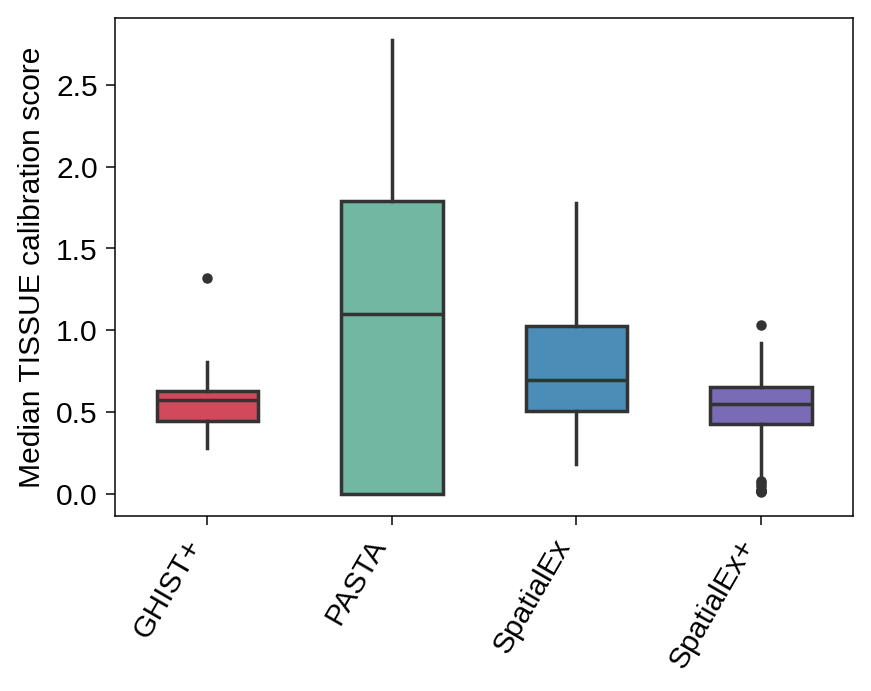

In [6]:
def compute_figure4c():
    rows = []
    for slide in SLIDES:
        data = SLIDE_DATA[slide]
        neighbors = cKDTree(data["xy"]).query(
            data["xy"], k=min(16, len(data["xy"]))
        )[1]
        if neighbors.ndim == 1:
            neighbors = neighbors[:, None]
        if neighbors.shape[1] != 16:
            raise ValueError(f"Slide {slide}: expected 16 TISSUE neighbours, found {neighbors.shape[1]}")

        scores = {
            method: tissue_calibration(
                data["target"], data["prediction"][method], neighbors
            )
            for method in METHODS
        }
        for index, gene in enumerate(data["genes"]):
            rows.append({
                "Slide": slide,
                "Gene": gene,
                **{
                    f"{method} median TISSUE calibration score": scores[method][index]
                    for method in METHODS
                },
                "Cell count": len(data["ids"]),
                "TISSUE neighbour count": neighbors.shape[1],
            })
        gc.collect()
    return pd.DataFrame(rows)


fig4c_tissue = compute_figure4c()
fig4c_coverage = {
    method: fig4c_tissue[f"{method} median TISSUE calibration score"].notna().sum()
    for method in METHODS
}
if len(fig4c_tissue) != 45 or any(count != 45 for count in fig4c_coverage.values()):
    raise ValueError(f"Expected 45 common slide-gene cases for every Fig. 4c method, found {fig4c_coverage}")
if not fig4c_tissue["TISSUE neighbour count"].eq(16).all():
    raise ValueError("Figure 4c must use the fixed 16-neighbour TISSUE protocol")
fig, axis = plt.subplots(figsize=(5, 4))
boxplot_methods(axis, fig4c_tissue, "median TISSUE calibration score")
axis.set_ylabel("Median TISSUE calibration score")
fig.tight_layout()
plt.show()

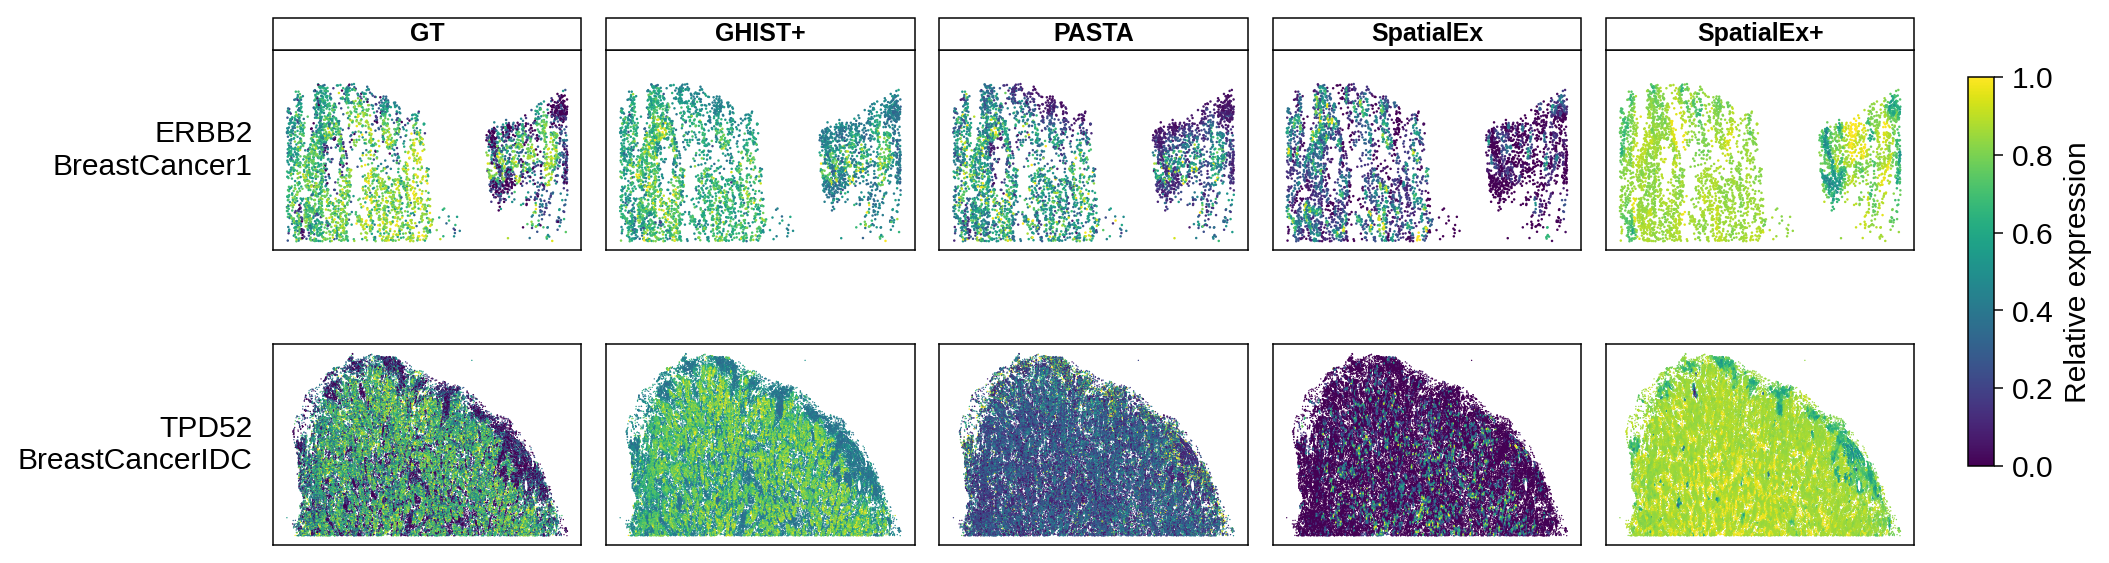

In [7]:
def compute_figure4e():
    rows = []
    for slide, gene in [(0, "ERBB2"), (1, "TPD52")]:
        data = SLIDE_DATA[slide]
        index = data["genes"].index(gene)
        values = {
            "GT": data["target"][:, index],
            **{
                method: data["prediction"][method][:, index]
                for method in METHODS
            },
        }
        scaled = {source: q99_scale(expression) for source, expression in values.items()}
        for cell_index, cell_id in enumerate(data["ids"]):
            rows.append({
                "Slide": slide,
                "Gene": gene,
                "Cell ID": int(float(cell_id)),
                "x coordinate": data["xy"][cell_index, 0],
                "y coordinate": data["xy"][cell_index, 1],
                **{
                    source: expression[cell_index]
                    for source, expression in scaled.items()
                },
            })
    return pd.DataFrame(rows)


fig4e_map = compute_figure4e()
sources = ["GT", *METHODS]
fig, axes = plt.subplots(2, 5, figsize=(12, 3.6))
for row, ((slide, gene), data) in enumerate(fig4e_map.groupby(["Slide", "Gene"], sort=False)):
    x = (data["x coordinate"] - data["x coordinate"].min()) / np.ptp(data["x coordinate"])
    y = 1 - (data["y coordinate"] - data["y coordinate"].min()) / np.ptp(data["y coordinate"])
    for column, source in enumerate(sources):
        axis = axes[row, column]
        image = axis.scatter(x, y, c=data[source], s=1 if len(data) < 10000 else 0.3, cmap="viridis", vmin=0, vmax=1, linewidths=0)
        if row == 0:
            facet_strip(axis, source, fontsize=10, height=0.16)
        if column == 0:
            axis.set_ylabel(
                f"{gene}\n{SLIDE_LABELS[slide]}",
                rotation=0, ha="right", va="center", labelpad=8,
            )
        axis.set_box_aspect(0.65)
        axis.set_xticks([])
        axis.set_yticks([])
        style_panel(axis)
fig.subplots_adjust(left=0.14, right=0.90, bottom=0.04, top=0.88, wspace=0.08, hspace=0.18)
color_axis = fig.add_axes([0.925, 0.20, 0.012, 0.60])
fig.colorbar(image, cax=color_axis, label="Relative expression")
plt.show()

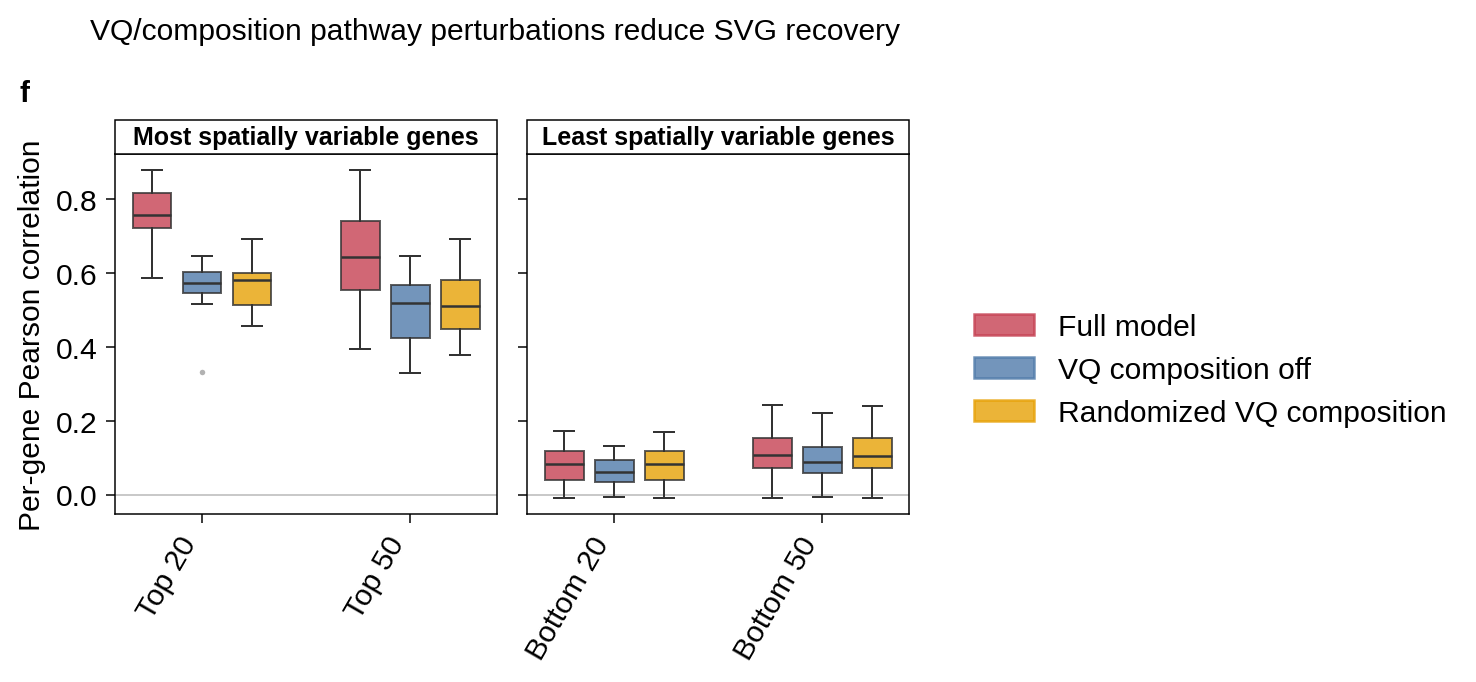

In [8]:
def compute_figure4f():
    gt = read_matrix(CONFIG["ablation_ground_truth"])
    coordinates = read_coordinates(CONFIG["ablation_coordinates"])
    predictions = {
        method: read_matrix(path)
        for method, path in ABLATION.items()
    }

    cells = common_ids(gt, coordinates, *predictions.values())
    genes = gt.columns
    for frame in predictions.values():
        genes = genes.intersection(frame.columns, sort=False)
    if len(cells) < 2 or len(genes) == 0:
        raise ValueError(f"Empty matched cohort: cells={len(cells)}, genes={len(genes)}")

    target_raw = gt.loc[cells, genes].to_numpy(np.float64)
    if not np.isfinite(target_raw).all() or np.min(target_raw) < 0:
        raise ValueError("Ground-truth raw counts are invalid")
    target = np.log1p(target_raw)
    prediction_values = {
        method: frame.loc[cells, genes].to_numpy(np.float64)
        for method, frame in predictions.items()
    }

    scores = giotto_scores(
        target,
        coordinates.loc[cells, ["x", "y"]].to_numpy(np.float64),
        8,
    ).astype(float)
    order = np.argsort(np.nan_to_num(scores, nan=-np.inf), kind="mergesort")[::-1]
    ranks = np.empty(len(genes), int)
    ranks[order] = np.arange(1, len(genes) + 1)

    result = pd.DataFrame({
        "Gene": genes.astype(str),
        "GT Giotto SVG score": scores,
        "SVG rank": ranks,
    })
    for method, values in prediction_values.items():
        result[f"{method} PCC"] = ablation_pearson(target, values)
    result = result.sort_values("SVG rank").reset_index(drop=True)

    coverage = {}
    for method in predictions:
        values = result[f"{method} PCC"].to_numpy(float)
        n_defined = int(np.isfinite(values).sum())
        coverage[method] = {
            "defined_genes": n_defined,
            "total_genes": int(len(values)),
            "coverage_fraction": float(n_defined / len(values)),
        }

    audit = {
        "full_run_is_reference": True,
        "slide_id": 3,
        "checkpoint_epoch_for_all_arms": 30,
        "common_cells": int(len(cells)),
        "common_genes": int(len(genes)),
        "input_cells": {
            "ground_truth": int(len(gt)),
            "coordinates": int(len(coordinates)),
            **{method: int(len(frame)) for method, frame in predictions.items()},
        },
        "input_genes": {
            "ground_truth": int(len(gt.columns)),
            **{method: int(len(frame.columns)) for method, frame in predictions.items()},
        },
        "ground_truth_transform": "log1p(raw counts)",
        "prediction_scale": "saved scaled-log predictions (PCC is scale invariant)",
        "svg_ranking": "GT-only Giotto rank correlation, k=8, shared cells",
        "undefined_pcc_policy": "constant or insufficient vectors are NA and excluded from summaries",
        "pcc_coverage": coverage,
        "prediction_sources": {
            method: public_path(path)
            for method, path in ABLATION.items()
        },
        "ground_truth_source": public_path(CONFIG["ablation_ground_truth"]),
        "coordinate_source": public_path(CONFIG["ablation_coordinates"]),
        "same_checkpoint_off_runtime": {
            "mode": "vq_comp_ctblend_off_inference",
            "checkpoint_relation": "same frozen Full-model checkpoint",
            "randomness_used": False,
            "training_performed": False,
            "runtime_overrides": {
                "vq_patch_ablation_off": True,
                "ct_prior_blend_alpha": 0.0,
            },
            "cell_type_classifier": "unchanged",
            "occurrence_path": "unchanged",
            "hurdle_exporter": "unchanged",
        },
        "randomized_vq_composition_runtime": {
            "mode": "global_shuffle_ctblend",
            "seed": 0,
            "intervention": "fixed random VQ prototypes with globally shuffled patch composition and cross-cell CT priors for reference-weight blending",
            "inject_cell": False,
            "cell_type_classifier": "unchanged",
            "ct_prior_ecrm_input": "unchanged",
            "occurrence_path": "unchanged",
            "hurdle_exporter": "unchanged",
        },
    }
    return result, audit

def summarise_figure4f(per_gene):
    cohorts = {
        "All genes": per_gene,
        "Top 20 SVGs": per_gene.nsmallest(20, "SVG rank"),
        "Top 50 SVGs": per_gene.nsmallest(50, "SVG rank"),
        "Bottom 20 non-SVGs": per_gene.nlargest(20, "SVG rank"),
        "Bottom 50 non-SVGs": per_gene.nlargest(50, "SVG rank"),
    }
    rows = []
    for cohort, subset in cohorts.items():
        for method in ABLATION:
            values = subset[f"{method} PCC"].to_numpy(float)
            values = values[np.isfinite(values)]
            rows.append({
                "Cohort": cohort,
                "Method": method,
                "Median PCC": float(np.median(values)) if values.size else np.nan,
                "Q1 PCC": float(np.quantile(values, 0.25)) if values.size else np.nan,
                "Q3 PCC": float(np.quantile(values, 0.75)) if values.size else np.nan,
                "Defined genes": int(values.size),
                "Requested genes": int(len(subset)),
            })
    return pd.DataFrame(rows)


fig4f_pcc, fig4f_audit = compute_figure4f()
fig4f_summary = summarise_figure4f(fig4f_pcc)
svg_summary = fig4f_summary[fig4f_summary["Cohort"].isin(["Top 20 SVGs", "Top 50 SVGs"])]
claim_supported = True
for cohort in ["Top 20 SVGs", "Top 50 SVGs"]:
    rows = svg_summary[svg_summary["Cohort"] == cohort].set_index("Method")["Median PCC"]
    claim_supported &= bool(rows["Full model"] > rows.drop("Full model").max())
fig4f_audit["claim_full_exceeds_both_controls_for_svg20_and_svg50"] = bool(claim_supported)

FIG4F_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
fig4f_pcc.to_csv(FIG4F_OUTPUT_DIR / "figure4f_per_gene_pcc_giotto.csv", index=False)
fig4f_summary.to_csv(FIG4F_OUTPUT_DIR / "figure4f_summary.csv", index=False)
with (FIG4F_OUTPUT_DIR / "figure4f_audit.json").open("w") as handle:
    json.dump(fig4f_audit, handle, indent=2, sort_keys=True)

methods = list(ABLATION)
method_colors = {
    "Full model": "#C43C4E",
    "VQ composition off": "#4C78A8",
    "Randomized VQ composition": "#E69F00",
}
fig, axes = plt.subplots(1, 2, figsize=(7, 4), sharey=True)
centers = np.array([0.0, 3.0])
offsets = np.array([-0.72, 0.0, 0.72])
all_box_values = []
for axis, (panel_title, take_smallest) in zip(
    axes,
    [("Most spatially variable genes", True), ("Least spatially variable genes", False)],
):
    data, positions, colors = [], [], []
    for group_idx, size in enumerate([20, 50]):
        subset = (
            fig4f_pcc.nsmallest(size, "SVG rank")
            if take_smallest
            else fig4f_pcc.nlargest(size, "SVG rank")
        )
        for method_idx, method in enumerate(methods):
            values = subset[f"{method} PCC"].to_numpy(float)
            values = values[np.isfinite(values)]
            data.append(values)
            all_box_values.append(values)
            positions.append(float(centers[group_idx] + offsets[method_idx]))
            colors.append(method_colors[method])
    boxplot = axis.boxplot(
        data,
        positions=positions,
        widths=0.56,
        patch_artist=True,
        showfliers=True,
        boxprops={"edgecolor": "#333333", "linewidth": 0.8},
        medianprops={"color": "#333333", "linewidth": 1.0},
        whiskerprops={"color": "#333333", "linewidth": 0.8},
        capprops={"color": "#333333", "linewidth": 0.8},
        flierprops={"marker": "o", "markersize": 2.2, "markerfacecolor": "#555555", "markeredgewidth": 0, "alpha": 0.45},
    )
    for patch, color in zip(boxplot["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_edgecolor("#333333")
        patch.set_alpha(0.78)
    axis.set_xticks(centers, ["Top 20", "Top 50"] if take_smallest else ["Bottom 20", "Bottom 50"], rotation=60, ha="right")
    axis.set_xlim(-1.25, 4.25)
    facet_strip(axis, panel_title, fontsize=10)
    style_panel(axis)

finite_values = np.concatenate([values for values in all_box_values if values.size])
value_min, value_max = float(finite_values.min()), float(finite_values.max())
padding = max(0.035, 0.05 * (value_max - value_min))
y_lower = max(-1.0, min(0.0, value_min) - padding)
y_upper = min(1.0, value_max + padding)
for axis in axes:
    axis.set_ylim(y_lower, y_upper)
    if y_lower < 0 < y_upper:
        axis.axhline(0, color="#B8B8B8", linewidth=0.6, zorder=0)
axes[0].set_ylabel("Per-gene Pearson correlation")
axes[1].tick_params(labelleft=False)
axes[0].text(
    -0.25, 1.13, "f",
    transform=axes[0].transAxes,
    fontweight="bold",
    fontsize=12,
    va="bottom",
    ha="left",
)
handles = [Patch(facecolor=method_colors[method], edgecolor=method_colors[method], alpha=0.78) for method in methods]
fig.legend(handles, methods, frameon=False, loc="center left", bbox_to_anchor=(0.78, 0.48))
takeaway = (
    "VQ/composition pathway perturbations reduce SVG recovery"
    if claim_supported
    else "VQ/composition controls show similar SVG recovery"
)
fig.suptitle(takeaway, x=0.10, y=0.97, ha="left", fontsize=12, fontweight="normal")
fig.subplots_adjust(left=0.12, right=0.75, bottom=0.28, top=0.78, wspace=0.08)
fig.savefig(FIG4F_OUTPUT_DIR / "figure4f_vq_ablation.png", dpi=300, facecolor="white")
fig.savefig(FIG4F_OUTPUT_DIR / "figure4f_vq_ablation.pdf", facecolor="white")
plt.show()